In [1]:
import sklearn as sk
import numpy as np
import pandas as pd
import seaborn as sns
import os


import matplotlib.pyplot as plt

In [12]:
df_all_features = pd.read_csv('C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/datasets/MT_dataset/patients_all_features.csv', delimiter=';')
endpoint_list = ["Aspiration_M06", "Dysphagia_M06", "Sticky_M06", "Taste_M06", "Xerostomia_M06"]
df_endpoints = pd.DataFrame()

In [13]:
df_all_features["Dysphagia_M06"].value_counts()


Dysphagia_M06
geen slikklachten/normaal eetpatroon / wel slikklachten, maar kan wel alles eten                                   535
geen slikklachten/normaal eetpatroon                                                                               207
alleen gepureerd/zacht voedsel                                                                                     147
wel slikklachten, maar kan wel alles eten                                                                           93
neussonde of PEG, maar nog wel orale intake mogelijk / neussonde of PEG, geen enkele orale intake meer mogelijk     73
alleen vloeibaar voedsel, geen sondevoeding                                                                         35
neussonde of PEG, maar nog wel orale intake mogelijk                                                                16
neussonde of PEG, geen enkele orale intake meer mogelijk                                                             7
Name: count, dtype: int64

In [14]:
tox_rating_conversions = {}

basic_conversion = {
    "Helemaal niet": 0,
    "Een beetje": 1,
    "Nogal": 2,
    "Heel erg": 3,
}
dysphagia_conversion = {
                "geen slikklachten/normaal eetpatroon / wel slikklachten, maar kan wel alles eten": 0,   # "Grade0_1",
                "geen slikklachten/normaal eetpatroon": 0, # "Grade0",
                "alleen gepureerd/zacht voedsel": 1, # "Grade2",
                "wel slikklachten, maar kan wel alles eten": 0, # "Grade1",
                "neussonde of PEG, maar nog wel orale intake mogelijk / neussonde of PEG, geen enkele orale intake meer mogelijk": 1, # "Grade3_4",
                "alleen vloeibaar voedsel, geen sondevoeding": 1, # "Grade3",
                "neussonde of PEG, maar nog wel orale intake mogelijk": 1, # "Grade4",
                "neussonde of PEG, geen enkele orale intake meer mogelijk": 1, # "Grade5",
            }


# basic_conversion = {
#     "Helemaal niet": 0,
#     "Een beetje": 0,
#     "Nogal": 1,
#     "Heel erg": 1,
# }
# dysphagia_conversion = {
#                 "geen slikklachten/normaal eetpatroon / wel slikklachten, maar kan wel alles eten": 0,   # "Grade0_1",
#                 "geen slikklachten/normaal eetpatroon": 0, # "Grade0",
#                 "alleen gepureerd/zacht voedsel": 2, # "Grade2",
#                 "wel slikklachten, maar kan wel alles eten": 1, # "Grade1",
#                 "neussonde of PEG, maar nog wel orale intake mogelijk / neussonde of PEG, geen enkele orale intake meer mogelijk": 3, # "Grade3_4",
#                 "alleen vloeibaar voedsel, geen sondevoeding": 3, # "Grade3",
#                 "neussonde of PEG, maar nog wel orale intake mogelijk": 4, # "Grade4",
#                 "neussonde of PEG, geen enkele orale intake meer mogelijk": 5, # "Grade5",
#             }

for endpoint in endpoint_list:
    if "dysphagia" in endpoint.lower():
        tox_rating_conversions[endpoint] = dysphagia_conversion
    else:
        tox_rating_conversions[endpoint] = basic_conversion

# df_all_features["Xerostomia_M06"].value_counts()

# col =  df_all_features["Xerostomia_M06"].replace(tox_rating_conversion)



for endpoint in endpoint_list:
    conv = tox_rating_conversions[endpoint]
    df_endpoints[endpoint] = df_all_features[endpoint].replace(conv)

# col.value_counts()
print("hi")

hi


C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_10848\3275943523.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_endpoints[endpoint] = df_all_features[endpoint].replace(conv)
C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_10848\3275943523.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_endpoints[endpoint] = df_all_features[endpoint].replace(conv)
C:\Users\d.c.macrae\AppData\Local\Temp\2\ipykernel_10848\3275943523.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a f

In [15]:
df_endpoints["Dysphagia_M06"].value_counts()


Dysphagia_M06
0.0    835
1.0    278
Name: count, dtype: int64

In [9]:
df_endpoints

,Aspiration_M06,Dysphagia_M06,Sticky_M06,Taste_M06,Xerostomia_M06
0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,1.0,1.0,1.0
2,0.0,0.0,1.0,0.0,1.0
3,0.0,NaN,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
1163,0.0,0.0,0.0,0.0,0.0
1164,0.0,0.0,1.0,0.0,1.0
1165,NaN,2.0,NaN,NaN,NaN
1166,0.0,0.0,1.0,0.0,1.0


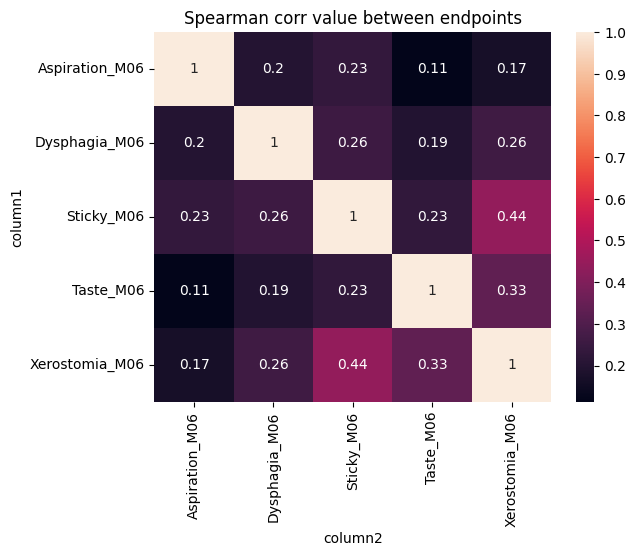

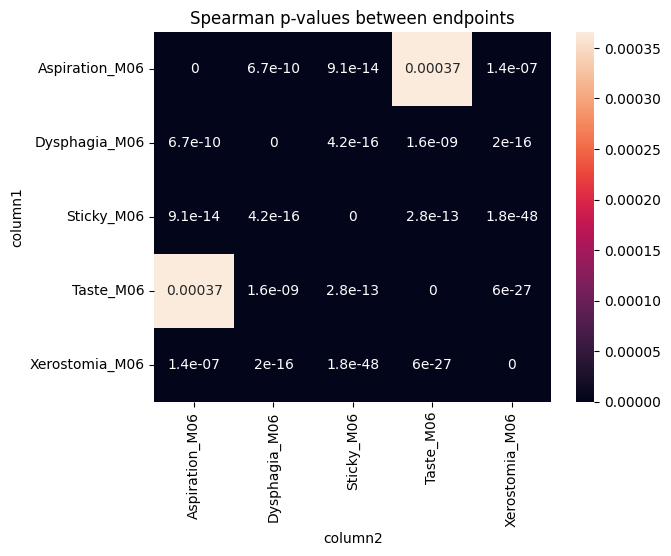

In [11]:
from scipy.stats import pearsonr, spearmanr

pearson_results = []
column_names = endpoint_list
for i in range(len(column_names)):
        for j in range(len(column_names)):
            nones = df_endpoints[column_names[i]].isnull() | df_endpoints[column_names[j]].isnull()
            corr, p_val = spearmanr(df_endpoints[column_names[i]][~nones], df_endpoints[column_names[j]][~nones], nan_policy="omit")
            #print(f"Correlation  {corr:.3f}, p-value {p_val} between {column_names[i]} and {column_names[j]}:)")

            pearson_results.append({
                "column1": column_names[i],
                "column2": column_names[j],
                "corr": corr,
                "p-value": p_val
            })
pearson_results = pd.DataFrame(pearson_results)
pearson_results.to_excel("spearman_corr.xlsx")

sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="corr"), annot=True)
plt.title("Spearman corr value between endpoints")
plt.savefig("spearman corr.pdf")
plt.show()
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Spearman p-values between endpoints")
plt.show()

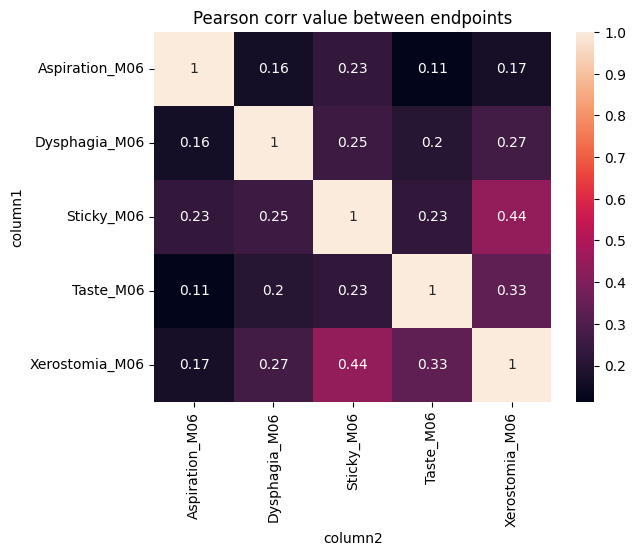

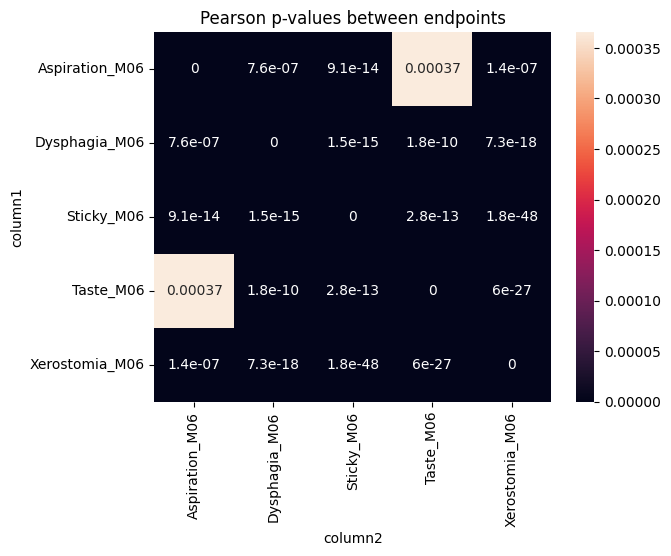

In [94]:
from scipy.stats import pearsonr

pearson_results = []
column_names = endpoint_list
for i in range(len(column_names)):
        for j in range(len(column_names)):
            nones = df_endpoints[column_names[i]].isnull() | df_endpoints[column_names[j]].isnull()
            corr, p_val = pearsonr(df_endpoints[column_names[i]][~nones], df_endpoints[column_names[j]][~nones])
            #print(f"Correlation  {corr:.3f}, p-value {p_val} between {column_names[i]} and {column_names[j]}:)")

            pearson_results.append({
                "column1": column_names[i],
                "column2": column_names[j],
                "corr": corr,
                "p-value": p_val
            })
pearson_results = pd.DataFrame(pearson_results)
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="corr"), annot=True)
plt.title("Pearson corr value between endpoints")
plt.show()
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Pearson p-values between endpoints")
plt.show()

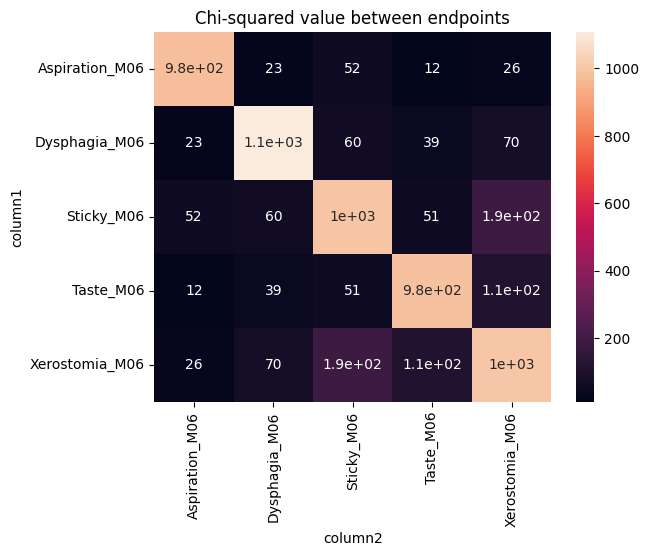

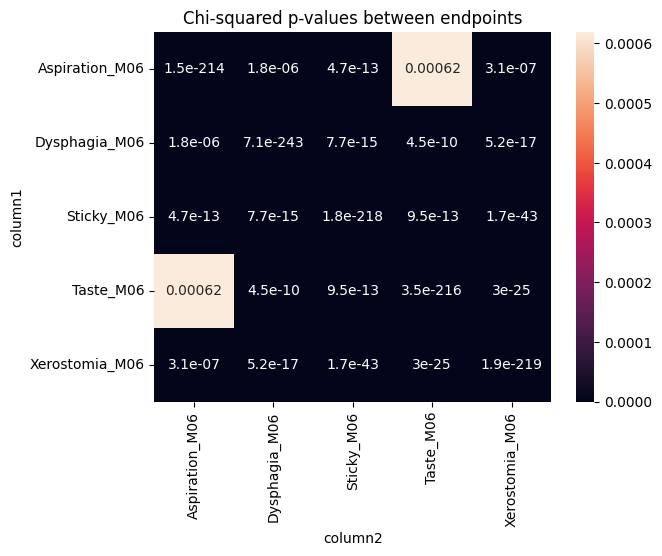

In [95]:
from scipy.stats import chi2_contingency

def chi_squared_corr(df, column_names):
    results = []
    for i in range(len(column_names)):
        for j in range(len(column_names)):
            nones = df_endpoints[column_names[i]].isnull() | df_endpoints[column_names[j]].isnull()
            crosstab = pd.crosstab(df[column_names[i]][~nones], df[column_names[j]][~nones])
            chi2, p, dof, expected = chi2_contingency(crosstab)
            results.append({
                "column1": column_names[i],
                "column2": column_names[j],
                "chi2": chi2,
                "p-value": p,
                "dof": dof,
                "expected": expected
            })
    return pd.DataFrame(results)

df_chi = chi_squared_corr(df_endpoints, endpoint_list)

sns.heatmap(df_chi.pivot(index="column1", columns="column2", values="chi2"), annot=True)
plt.title("Chi-squared value between endpoints")
plt.show()
sns.heatmap(df_chi.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Chi-squared p-values between endpoints")
plt.show()

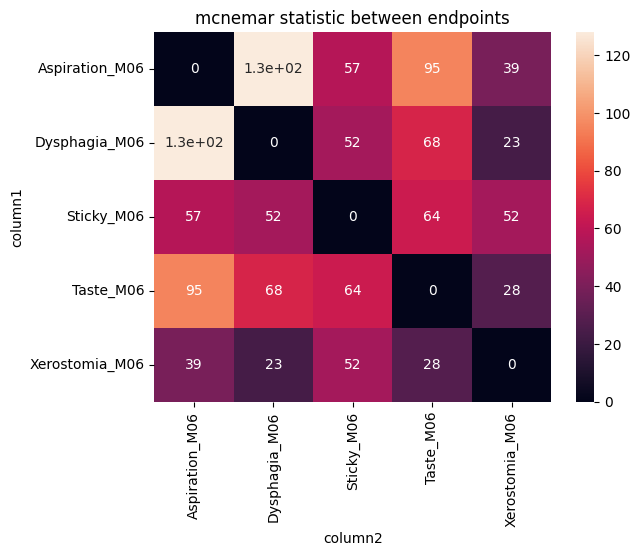

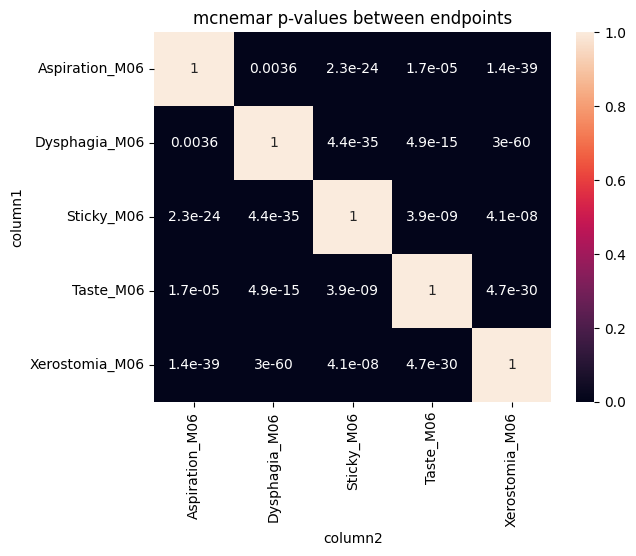

In [17]:
from statsmodels.stats.contingency_tables import mcnemar

def chi_squared_corr(df, column_names):
    results = []
    for i in range(len(column_names)):
        for j in range(len(column_names)):
            nones = df_endpoints[column_names[i]].isnull() | df_endpoints[column_names[j]].isnull()
            crosstab = pd.crosstab(df[column_names[i]][~nones], df[column_names[j]][~nones])
            #print(crosstab)
            result = mcnemar(crosstab)
            results.append({
                "column1": column_names[i],
                "column2": column_names[j],
                "mcnemar stat": result.statistic,
                "p-value": result.pvalue,
                # "dof": dof,
                # "expected": expected
            })
    return pd.DataFrame(results)

df_chi = chi_squared_corr(df_endpoints, endpoint_list)
df_chi.to_excel("mcnemar.xlsx")
df_chi = pd.read_excel("mcnemar.xlsx")

sns.heatmap(df_chi.pivot(index="column1", columns="column2", values="mcnemar stat"), annot=True)
plt.title("mcnemar statistic between endpoints")
plt.savefig("mcnemar_stat.pdf")
plt.show()
sns.heatmap(df_chi.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("mcnemar p-values between endpoints")
plt.show()

In [ ]:
from scipy.stats.contingency_tables import mcnemar

def chi_squared_corr(df, column_names):
    results = []
    for i in range(len(column_names)):
        for j in range(len(column_names)):
            nones = df_endpoints[column_names[i]].isnull() | df_endpoints[column_names[j]].isnull()
            crosstab = pd.crosstab(df[column_names[i]][~nones], df[column_names[j]][~nones])
            chi2, p, dof, expected = chi2_contingency(crosstab)
            results.append({
                "column1": column_names[i],
                "column2": column_names[j],
                "chi2": chi2,
                "p-value": p,
                "dof": dof,
                "expected": expected
            })
    return pd.DataFrame(results)

df_chi = chi_squared_corr(df_endpoints, endpoint_list)

sns.heatmap(df_chi.pivot(index="column1", columns="column2", values="chi2"), annot=True)
plt.title("Chi-squared value between endpoints")
plt.show()
sns.heatmap(df_chi.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Chi-squared p-values between endpoints")
plt.show()

![title](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# DOSE

In [18]:
df_all_features = pd.read_csv('C:/Users/d.c.macrae/Documents/DL_NTCP_Multitox/datasets/MT_dataset/stratified_sampling_full_542.csv', delimiter=';')
loctum_mapping = {
                'Categorie: overig' : "Overig",
                'Hypofarynx' : "Pharynx",
                'Larynx' : "Larynx",
                'Nasopharynx' : "Pharynx",
                'Neus(bij)holte' : "Overig",
                'Oral Cavity' : "Oral_Cavity",
                'Oropharynx' : "Pharynx"}
df_all_features["Loctum2"] = df_all_features["Loctum2"].replace(loctum_mapping)

df_all_features

,PatientID,Sex,Age,CT+C_available,CT_Artefact,Loctum2,Photons,T_stage,N_stage,Smoking,...,Taste_W01_Nogal,Taste_W01_Nogal_Heel_erg,Dysphagia_W01_Grade0_1,Dysphagia_W01_Grade2,Dysphagia_W01_Grade3_4,Dysphagia_W01_Nogal,Dysphagia_W01_Heel_erg,Dysphagia_W01_Een_beetje,Dysphagia_W01_Helemaal_niet,Chemotherapy
0,5680,1,0.68,1.0,0.0,Larynx,1.0,T2,N0,1,...,0,0,1,0,0,0,0,0,0,0
1,20715,1,0.56,1.0,0.0,Pharynx,1.0,T4,N1,1,...,0,0,1,0,0,0,0,0,0,1
2,21879,1,0.67,1.0,0.0,Pharynx,1.0,T2,N2,1,...,0,0,1,0,0,0,0,0,0,1
3,52277,1,0.50,1.0,0.0,Pharynx,1.0,T4,N2,1,...,0,0,0,1,0,0,0,0,0,1
4,59896,1,0.51,1.0,0.0,Pharynx,1.0,T2,N2,1,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,9946432,1,0.75,1.0,0.0,Larynx,1.0,T3,N0,1,...,0,0,1,0,0,0,0,0,0,0
1086,9949620,1,0.75,0.0,0.0,Larynx,1.0,T1,N0,0,...,0,0,1,0,0,0,0,0,0,0
1087,9956433,1,0.66,1.0,1.0,Pharynx,1.0,T2,N2,0,...,0,0,1,0,0,0,0,0,0,1
1088,9977441,1,0.50,1.0,0.0,Larynx,1.0,T3,N0,0,...,0,0,1,0,0,0,0,0,0,0


In [19]:
dose_columns = df_all_features.columns[df_all_features.columns.str.contains("meandose")]
dose_columns

Index(['Parotid_L_meandose', 'Parotid_R_meandose', 'Parotid_meandose',
       'Submandibular_L_meandose', 'Submandibular_R_meandose',
       'Submandibular_meandose', 'PCM_Sup_meandose', 'PCM_Med_meandose',
       'PCM_Inf_meandose', 'Crico_meandose', 'Supraglottic_meandose',
       'OralCavity_Ext_meandose', 'BuccalMucosa_L_meandose',
       'BuccalMucosa_R_meandose', 'BuccalMucosa_meandose',
       'TongueTop_meandose', 'External_meandose', 'PCM_meandose',
       'Esophagus_Cerv_meandose'],
      dtype='object')

In [20]:
CITOR_doses = ["Submandibular_meandose", "Parotid_meandose",  'PCM_Sup_meandose', 'PCM_Med_meandose', 'PCM_Inf_meandose', 'OralCavity_Ext_meandose'] + ["Loctum2"]

df_CITOR_doses = df_all_features[CITOR_doses]
df_CITOR_doses

,Submandibular_meandose,Parotid_meandose,PCM_Sup_meandose,PCM_Med_meandose,PCM_Inf_meandose,OralCavity_Ext_meandose,Loctum2
0,1.013139,0.326766,0.544177,8.848484,50.582483,0.555905,Larynx
1,58.693037,22.460510,66.051506,38.330428,16.787087,56.676119,Pharynx
2,57.937461,31.789204,67.438013,53.527220,25.805898,49.755277,Pharynx
3,62.009299,32.809701,58.868152,41.697859,30.940294,63.163352,Pharynx
4,62.717922,31.979660,60.347738,52.272689,29.809969,44.783982,Pharynx
...,...,...,...,...,...,...,...
1085,49.311730,18.786567,30.550568,56.092516,61.237233,20.274995,Larynx
1086,1.111487,0.084342,0.249860,8.676321,50.042890,0.205955,Larynx
1087,59.141604,25.588652,60.431882,46.646579,32.985069,52.527735,Pharynx
1088,43.205165,17.182238,36.498781,47.614415,59.675797,17.120248,Larynx


In [21]:
sns.pairplot(df_CITOR_doses, hue="Loctum2")
plt.show()

Parotid_meandose
Correlation  0.834, p-value 3.7144116765839223e-283        Parotid_meandose and Submandibular_meandose
Correlation  0.837, p-value 1.61786947481832e-287        Parotid_meandose and PCM_Sup_meandose
Correlation  0.720, p-value 1.2733642373697627e-174        Parotid_meandose and PCM_Med_meandose
Correlation  0.064, p-value 0.03566861641873117        Parotid_meandose and PCM_Inf_meandose
Correlation  0.843, p-value 7.803959980237741e-295        Parotid_meandose and OralCavity_Ext_meandose
Submandibular_meandose
Correlation  0.867, p-value 0.0        Submandibular_meandose and PCM_Sup_meandose
Correlation  0.852, p-value 1.227615206545919e-307        Submandibular_meandose and PCM_Med_meandose
Correlation  0.028, p-value 0.34788413935672124        Submandibular_meandose and PCM_Inf_meandose
Correlation  0.833, p-value 1.722182432584966e-281        Submandibular_meandose and OralCavity_Ext_meandose
PCM_Sup_meandose
Correlation  0.761, p-value 1.146454811931981e-206        P

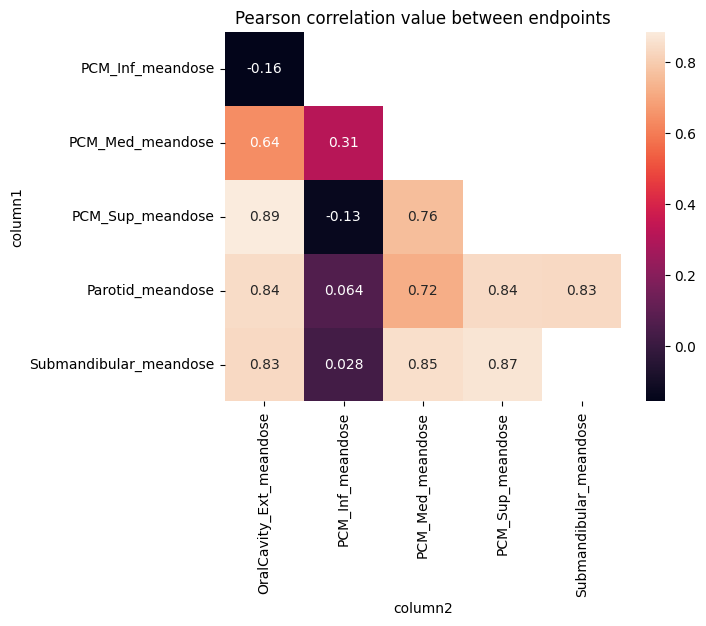

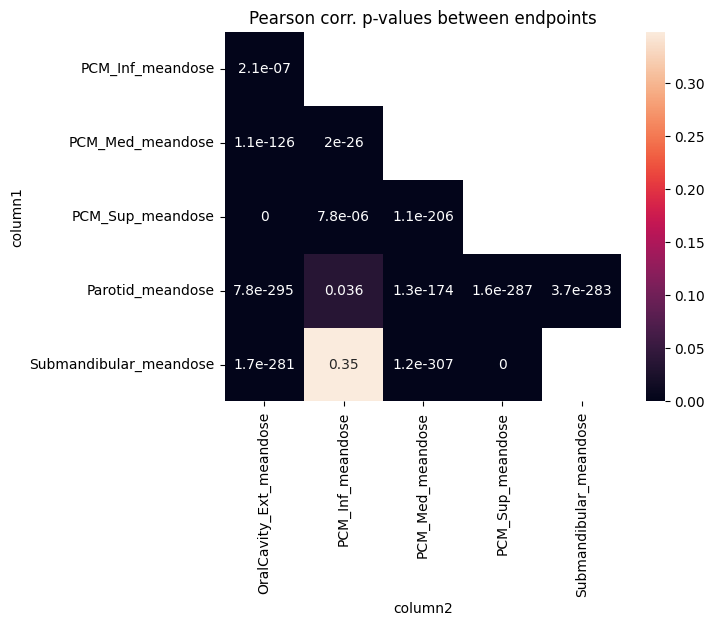

In [106]:
from scipy.stats import pearsonr

pearson_results = []
column_names = ["Parotid_meandose", "Submandibular_meandose", 'PCM_Sup_meandose', 'PCM_Med_meandose', 'PCM_Inf_meandose', 'OralCavity_Ext_meandose']
for i in range(len(column_names)):
        print(column_names[i])
        for j in range(i+1, len(column_names)):
            nones = df_CITOR_doses[column_names[i]].isnull() | df_CITOR_doses[column_names[j]].isnull()
            corr, p_val = pearsonr(df_CITOR_doses[column_names[i]][~nones], df_CITOR_doses[column_names[j]][~nones])
            print(f"Correlation  {corr:.3f}, p-value {p_val}        {column_names[i]} and {column_names[j]}")

            pearson_results.append({
                "column1": column_names[i],
                "column2": column_names[j],
                "corr": corr,
                "p-value": p_val
            })

#fig, axis = plt.subplots(1, 2, figsize=(12, 6))
pearson_results = pd.DataFrame(pearson_results)
pearson_results.to_excel("pearson_corr_dose.xlsx")
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="corr"), annot=True,)
plt.title("Pearson correlation value between endpoints")
plt.savefig("pearson_corr.pdf")
plt.show()
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Pearson corr. p-values between endpoints")
plt.show()

In [96]:
len(df_CITOR_doses)

1090

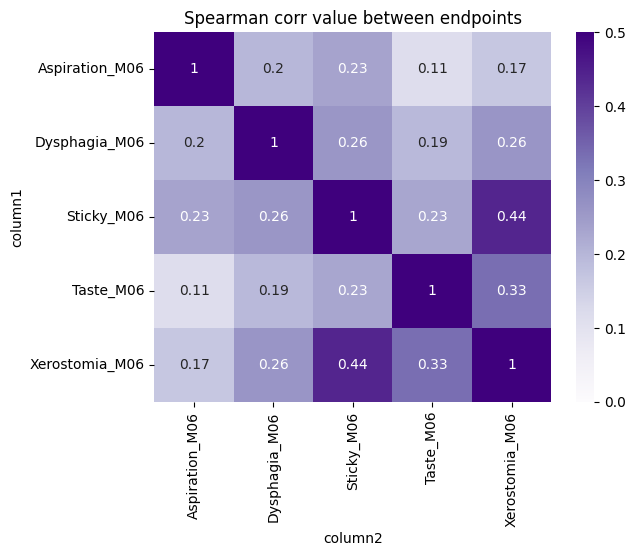

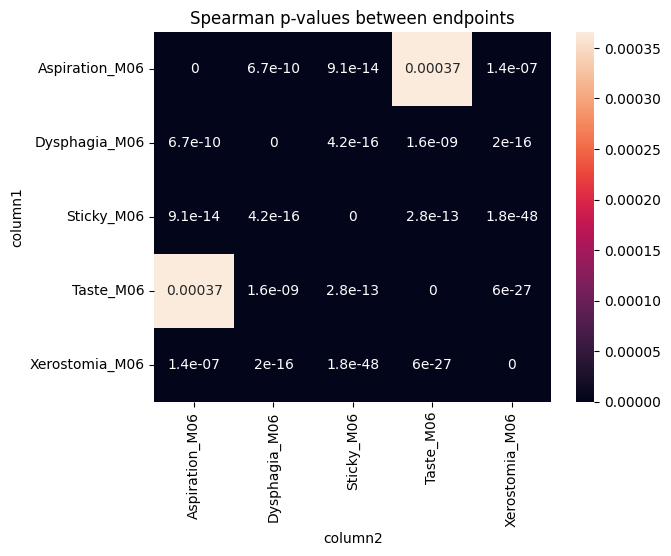

In [24]:
pearson_results = pd.read_excel("spearman_corr.xlsx")
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="corr"), annot=True, cmap="Purples", vmin=0, vmax=0.5)
plt.title("Spearman corr value between endpoints")
plt.savefig("spearman corr.pdf")
plt.show()
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Spearman p-values between endpoints")
plt.show()

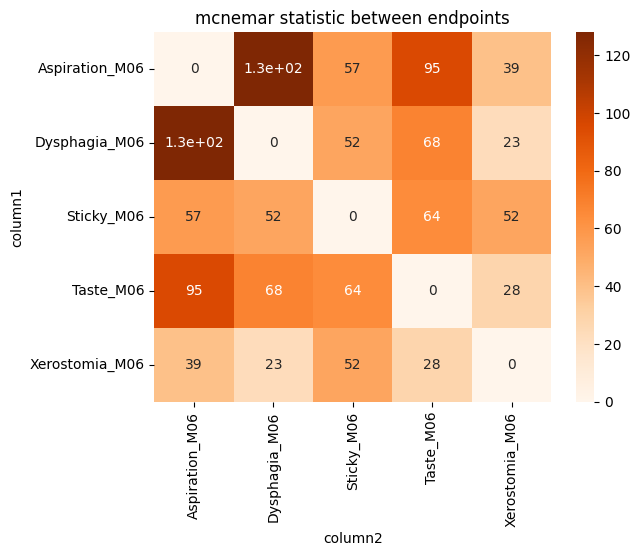

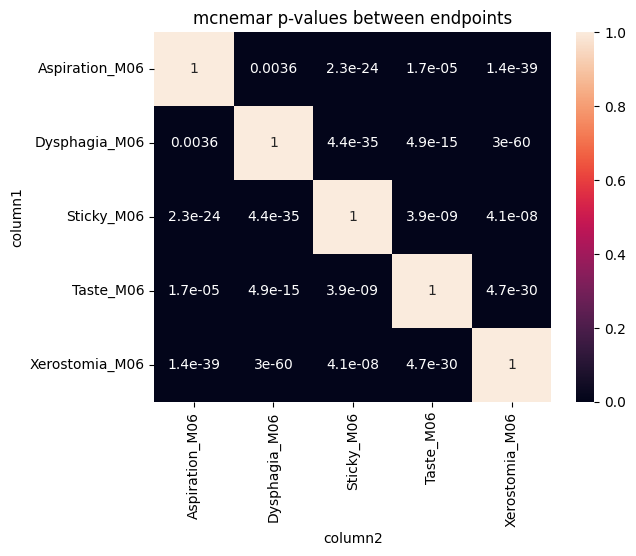

In [26]:
df_mcnemar = pd.read_excel("mcnemar.xlsx")

sns.heatmap(df_mcnemar.pivot(index="column1", columns="column2", values="mcnemar stat"), annot=True, cmap="Oranges")
plt.title("mcnemar statistic between endpoints")
plt.savefig("mcnemar_stat_orange.pdf")
plt.show()
sns.heatmap(df_mcnemar.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("mcnemar p-values between endpoints")
plt.show()

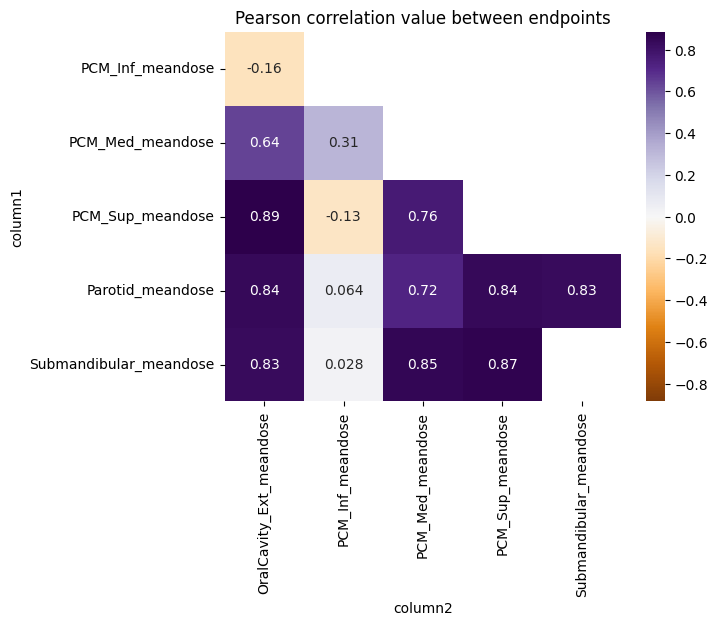

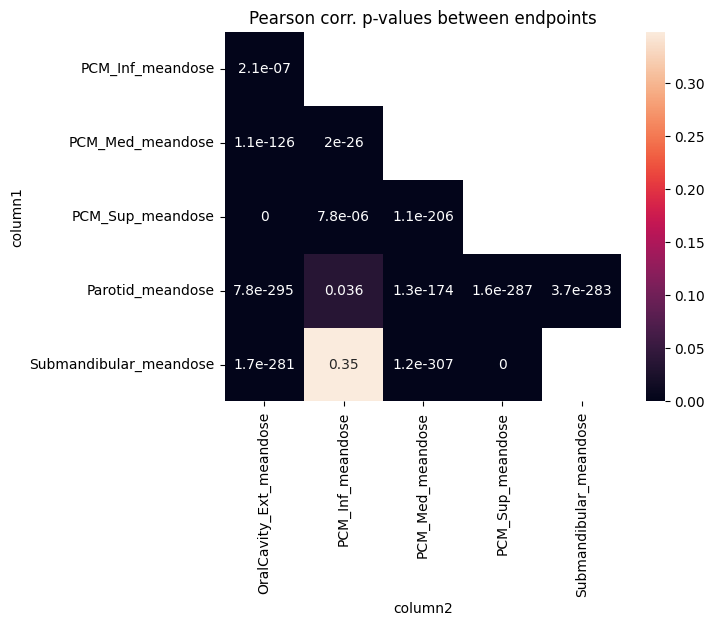

In [20]:
pearson_results = pd.read_excel("pearson_corr_dose.xlsx")

from matplotlib import cm
import matplotlib.colors as colors
cmap = cm.PuOr
#cmap = cm.PRGn

sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="corr"), annot=True, norm=colors.CenteredNorm(), cmap=cmap)
plt.title("Pearson correlation value between endpoints")
plt.savefig("pearson_corr.pdf")
plt.show()
sns.heatmap(pearson_results.pivot(index="column1", columns="column2", values="p-value"), annot=True)
plt.title("Pearson corr. p-values between endpoints")
plt.show()